In [10]:
# --- Celda 1.1: Importaciones y Carga de Librerías Offline ---
import os
import numpy as np
import pandas as pd
import glob
import ROOT
import time
import traceback
from multiprocessing import Pool, cpu_count
from functools import partial
import matplotlib.pyplot as plt

In [2]:
# Esta es la parte MÁS IMPORTANTE:
# Asegúrate de que estás corriendo este Jupyter Lab desde una terminal
# donde ANTES hiciste: source /ruta/a/auger/offline/this-auger-offline.sh

AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError(
        "AUGEROFFLINEROOT no definido. "
        "Reinicia Jupyter Lab desde una terminal donde hayas "
        "hecho: "
        " 'aug_set_version offline 4.0.1-icrc23-prod1-root6' "   
        " 'source /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6/bin/this-auger-offline.sh'."
    )

print(f"AUGEROFFLINEROOT encontrado en: {AugerOfflineRoot}")

# Cargar las librerías necesarias
print("Cargando librerías de Auger Offline...")
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    lib_path = os.path.join(AugerOfflineRoot, "lib", lib)
    if not os.path.exists(lib_path):
        raise FileNotFoundError(f"No se encontró la librería: {lib_path}")
    
    # Usamos gSystem.Load que es más robusto en PyROOT
    status = ROOT.gSystem.Load(lib_path)
    if status < 0:
        raise ImportError(f"Error cargando la librería: {lib_path}")

print("Librerías cargadas correctamente. ¡Listo para trabajar! 🚀")

AUGEROFFLINEROOT encontrado en: /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6
Cargando librerías de Auger Offline...
Librerías cargadas correctamente. ¡Listo para trabajar! 🚀


In [3]:
# --- Celda 2.1: Funciones Auxiliares y Principales (con nMuones_MC) ---

def getModuleList(counter, sim=True):
    """
    Obtiene la lista de objetos 'Module' (segmentos de detector)
    asociados a un 'Counter' (estación UMD).
    
    Parameters:
    ----------
    counter : ROOT.mevt.Counter
        La estación UMD de la cual extraer los módulos.
    sim : bool, default=True
        Flag para indicar si son datos de simulación.
        - True (Simulación): IDs de módulo son 0, 1, 2...
        - False (Datos Reales): IDs de módulo son 100, 101, 102...
    """
    possibleModules = range(0, 6) if sim else range(100, 116)
    modules = []
    for modId in possibleModules:
        if counter.HasModule(modId):
            modules.append(counter.GetModule(modId))
    return modules

def readADST_surface_v8(fname, is_mc_simulation=True):
    """
    Leer un archivo ADST (1 fila por MÓDULO).
    
    Esta función es el corazón del pipeline de procesamiento. Itera sobre
    cada evento (lluvia) en un archivo ADST y extrae la información
    relevante a nivel de MÓDULO de UMD (el nivel más granular).
    
    Lógica Clave:
    1. Itera sobre el MDEvent (mEvent.CountersBegin()) para encontrar
       TODOS los counters UMD (tanto Infill '104k' como Anillo Denso '90k').
    2. Usa el SDEvent como "diccionario" de geometría para obtener r y phi.
    3. NO filtra por 'IsLowGainSaturated', en su lugar, guarda un flag.
    4. Corrige el cálculo de 'phi_plane' para el Infill (igual que el Anillo Denso).
    5. Guarda la señal REC ('nMuones_REC') y la señal MC ('nMuones_MC')
       para cada módulo individual.
    """
    
    print(f"Iniciando lectura de: {os.path.basename(fname)}")
    
    if not os.path.exists(fname):
        print(f"Advertencia: Archivo no encontrado {fname}")
        return pd.DataFrame() # Retorna DF vacío

    # --- Inicialización de ROOT ---
    files = ROOT.std.vector('string')()
    files.push_back(fname)

    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    
    file1.ReadDetectorGeometry(geo) # Ignoramos fallos (Warnings de TStreamerInfo)
    file1.SetBuffers(event)

    data = [] 
    event_count = 0
    start_time = time.time()

    # --- COMIENZA EL BUCLE DE EVENTOS ---
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        event_count += 1
        if event_count % 500 == 0:
            print(f"... procesados {event_count} eventos.")

        # --- Info Global del Evento (Lluvia) ---
        event_id_lluvia = event.GetEventId()
        
        MCShower = event.GetGenShower()
        mc_energy = MCShower.GetEnergy()
        logE_MC = np.log10(mc_energy) if mc_energy > 0 else np.nan
        theta_MC = MCShower.GetZenith() * 180.0 / np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0 / np.pi
        primary = MCShower.GetShortPrimaryName()
        
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        rec_energy = sShower.GetEnergy()
        logE_REC = np.log10(rec_energy) if rec_energy > 0 else np.nan
        theta_REC = sShower.GetZenith() * 180.0 / np.pi
        phi_REC = sShower.GetAzimuth() * 180.0 / np.pi
        
        # Azimut de la lluvia REC. Lo necesitamos para el cálculo de phi_rel
        shower_azimuth_rec = sShower.GetAzimuth()
        
        # --- Bucle sobre los COUNTERS (Estaciones UMD) ---
        mEvent = event.GetMDEvent()
        counterIterator = mEvent.CountersBegin()
        countersEnd = mEvent.CountersEnd()
        
        while counterIterator != countersEnd:
            
            counter = counterIterator.__deref__() # Objeto Counter (estación)
            counterId = counter.GetId()           
            sdId = counter.GetSdPartnerId()    

            # Buscamos la estación de superficie (SD) asociada
            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            
            # --- Corte de Calidad 1: Geometría ---
            # Si no hay sdStation, no podemos calcular r_core ni phi_plane.
            # Ese counter no sirve para el análisis de asimetría.
            if sdStation is None:
                counterIterator += 1 # Avanzamos al siguiente counter
                continue 
            
            # --- Corte de Calidad 2: Saturación (Corte Diferido) ---
            # Guardamos el flag, como discutimos, en lugar de filtrar.
            is_sd_saturated = sdStation.IsLowGainSaturated()

            # --- Info de Geometría y Señal (Nivel Estación) ---
            r = sdStation.GetSPDistance()
            r_core = r
            r_core_err = sdStation.GetSPDistanceError()
            sdSignal = sdStation.GetTotalSignal()
            sdSignal_err = sdStation.GetTotalSignalError()
            sdMuonSignal = sdStation.GetMuonSignal()
            
            # --- ❗️ CORRECCIÓN DE PHI (¡Clave!) ❗️ ---
            station_azimuth_sp = sdStation.GetAzimuthSP()
            
            # Tanto para el INFILL como para el ANILLO DENSO (90k): El ángulo ya es relativo al eje de la lluvia.
            phi_rel = station_azimuth_sp
            
            # Calculamos X, Y (en plano de lluvia) y phi_plane [0, 2*pi]
            x_plane = r * np.cos(phi_rel)
            y_plane = r * np.sin(phi_rel)
            phi_plane = (phi_rel + 2 * np.pi) % (2 * np.pi)
            
            # --- OBTENER INFO MC (Nivel Estación) ---
            # Necesitamos el "gemelo" de simulación del counter
            simCounter = mEvent.GetSimCounter(counterId)
            if simCounter is None:
                # Si no hay simCounter (raro), no podremos obtener
                # nMuones_MC. Saltamos esta estación.
                counterIterator += 1
                continue
            
            # --- Bucle sobre los MÓDULOS (Segmentos) ---
            modules = getModuleList(counter, sim=is_mc_simulation)
            for module in modules:
                
                # --- Señal Reconstruida (REC) ---
                nMuones_REC = module.GetNumberOfEstimatedMuons()
                moduleId = module.GetId()

                # --- Estado del Módulo (Flag de Calidad) ---
                if module.IsCandidate(): status = "candidate"
                elif module.IsSaturated(): status = "saturated"
                elif module.IsRejected(): status = "rejected"
                elif module.IsSilent(): status = "silent"
                else: status = "undefined"
                
                # --- ❗️ CÁLCULO DE MUONES MC (Verdad) ❗️ ---
                # Inspo Carmi: Iteramos por los 2 canales (scintillators)
                # de este módulo y sumamos los muones MC "inyectados".
                nMuones_MC_module = 0.0
                channelIterator = module.ChannelsBegin()
                channelsEnd = module.ChannelsEnd()
                
                while channelIterator != channelsEnd:
                    channel = channelIterator.__deref__()
                    channelId = channel.GetId()
                    
                    # Le preguntamos al 'simCounter' por el 'simScintillator'
                    # que corresponde a este 'moduleId' y 'channelId'
                    if simCounter.HasSimScintillatorByChannel(moduleId, channelId):
                        mdSimScintillator = simCounter.GetSimScintillatorByChannelId(moduleId, channelId)
                        # ¡Obtenemos la verdad MC!
                        nMuones_MC_module += mdSimScintillator.GetNumberOfInjectedMuons()
                    
                    channelIterator += 1
                # --- ❗️ FIN DEL CÁLCULO MC ❗️ ---


                data.append({
                    "event_id": event_id_lluvia,
                    
                    # Info MC
                    "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
                    
                    # Info REC
                    "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
                    
                    # Info Módulo/Counter
                    "counterId": counterId,
                    "moduleId": moduleId,
                    "nMuones_REC": nMuones_REC,   # <-- ❗️ RENOMBRADO
                    "nMuones_MC": nMuones_MC_module, # <-- ❗️ NUEVA COLUMNA
                    "module_status": status,      
                    "is_sd_saturated": is_sd_saturated, 
                    
                    # Info de Geometría (plano de lluvia)
                    "x_plane": x_plane,
                    "y_plane": y_plane,
                    "phi_plane": phi_plane, # <-- ¡Ahora está bien calculado!
                    "r_core": r_core,
                    "r_core_err": r_core_err,     
                    
                    # Info de Señal (SD)
                    "sdId": sdId,
                    "sdSignal": sdSignal,
                    "sdSignal_err": sdSignal_err,
                    "sdMuonSignal": sdMuonSignal  
                })

                
            counterIterator += 1 # Avanzamos al siguiente counter
        
    end_time = time.time()
    elapsed = end_time - start_time
    
    print(f"Lectura completa. Total de eventos leídos: {event_count}")
    print(f"Tiempo total de lectura: {elapsed:.2f} segundos.")
    print(f"Total de 'MÓDULOS' (filas) extraídos: {len(data)}")

    df = pd.DataFrame(data)
    return df

In [6]:
# -----------------------------------------------------------------
# FUNCIÓN "TRABAJADORA"
# ❗️ 2. AHORA ACEPTA 'output_dir' COMO ARGUMENTO
# -----------------------------------------------------------------
def process_file_wrapper(root_fpath, output_dir):
    
    # 1. Definir rutas
    filename = os.path.basename(root_fpath)
    output_filename = filename.replace(".root", ".parquet")
    output_path = os.path.join(output_dir, output_filename)
    
    # 2. Evitar reprocesar
    if os.path.exists(output_path):
        return f"INFO: El archivo ya existe, saltando: {output_filename}"

    # 3. Imprimir estado
    print(f"► [Iniciando]: {filename}")
    
    try:
        # ----- INICIO DEL TRABAJO -----
        start_file_time = time.time()
        
        # 1. Leer el .root (¡Llama a la función de la Celda 2.1!)
        # (Asegurate de que tu Celda 2.1 se llame 'readADST_surface' 
        # o cambiá el nombre aquí abajo)
        df = readADST_surface_v8(root_fpath) 
        
        if df.empty:
            return f"INFO: Archivo vacío o sin datos UMD. Saltando: {filename}"

        # 2. Extraer metadatos del nombre de archivo
        try:
            parts = filename.split('_')
            df["model_mc"] = parts[0]
            df["e_min_mc"] = float(parts[1]) / 10.0
            df["e_max_mc"] = float(parts[2]) / 10.0
            df["primary_name_mc"] = parts[3]
            run_part = parts[-1].replace('.root', '')
            df["run_number"] = int(run_part.replace('Run', ''))
        except Exception as e_parse:
            print(f"  Advertencia: No se pudo parsear metadata en {filename}: {e_parse}")

        # 3. Guardar en Parquet
        df.to_parquet(
            output_path,
            compression="snappy",
            index=False
        )
        
        # 4. Liberar memoria
        del df
        
        end_file_time = time.time()
        elapsed = end_file_time - start_file_time
        return f"✔ [Éxito]: {filename} -> {output_filename} ({elapsed:.2f}s)"

        # ----- FIN DEL TRABAJO -----

    except Exception as e:
        # Si algo falla, retornamos el string de error
        return f"❌ [ERROR] en {filename}: {e}\n{traceback.format_exc()}"

In [7]:
# -----------------------------------------------------------------
# SCRIPT PRINCIPAL
# -----------------------------------------------------------------

print("--- INICIANDO PROCESO PARALELO (4 Workers) ---")
start_total_time = time.time()

# --- 1. Configuración de Rutas ---
base_path = "/srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium"
output_dir = "/home/lsilva/Github/ADST_Alexey_module_v5/parquet_sib_helio_17/"

os.makedirs(output_dir, exist_ok=True)
print(f"Buscando archivos en: {base_path}")
print(f"Los archivos .parquet se guardarán en: {output_dir}")

# --- 2. Encontrar todos los archivos ---
all_root_files = glob.glob(os.path.join(base_path, "*.root"))
all_root_files.sort()

if not all_root_files:
    print(f"¡Error! No se encontraron archivos .root en: {base_path}")
else:
    print(f"Encontrados {len(all_root_files)} archivos .root para procesar.")

    # --- 3. Bucle de Procesamiento Paralelo ---
    n_workers = 4  # Ajustar como sea necesario
    print(f"Iniciando Pool con {n_workers} trabajadores...")
    
    # CREAMOS LA FUNCIÓN "PARCIAL" 
    # "Congelamos" el argumento 'output_dir' de nuestra función wrapper
    process_func = partial(process_file_wrapper, output_dir=output_dir)

    with Pool(processes=n_workers) as pool:
        
        # pool.map() distribuye la lista 'all_root_files'
        # entre los 4 trabajadores y aplica la función 'process_file_wrapper'
        # results' será una lista con los strings de "Éxito" o "ERROR"
        results = pool.map(process_func, all_root_files)
        
    print("\n\n--- Proceso Paralelo Completado ---")

    # --- 4. Resumen Final ---
    exitos = 0
    errores = 0
    
    # Imprimimos todos los mensajes de resultado
    for res in results:
        print(res)
        if "✔ [Éxito]" in res:
            exitos += 1
        elif "❌ [ERROR]" in res:
            errores += 1

    end_total_time = time.time()
    print("\n--- Resumen de la Tanda ---")
    print(f"Tiempo total: {(end_total_time - start_total_time) / 60:.2f} minutos")
    print(f"Total de archivos: {len(all_root_files)}")
    print(f"Éxitos: {exitos}")
    print(f"Errores: {errores}")
    print(f"¡Listo! Tus archivos .parquet están en: {output_dir}")

--- INICIANDO PROCESO PARALELO (4 Workers) ---
Buscando archivos en: /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium
Los archivos .parquet se guardarán en: /home/lsilva/Github/ADST_Alexey_module_v5/parquet_sib_helio_17/
Encontrados 20 archivos .root para procesar.
Iniciando Pool con 4 trabajadores...
► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run012.root► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run031.root► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run014.root



Iniciando lectura de: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run012.rootIniciando lectura de: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run031.rootIniciando lectura de: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.rootIniciando lectura de: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLU

  input file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root
  input file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run014.root
  input file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run031.root
  input file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run012.root
Warning in <TStreamerInfo::BuildCheck>: 
   The StreamerInfo of class Detector read from file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run014.root
   has the sam

🚀 INICIANDO VALIDACIÓN DEL FIX EN: /home/lsilva/Github/ADST_Alexey_module_v6/parquet_sib_helio_17/
... Cargando datos ...
✅ Datos filtrados: 97002 módulos Infill (r=400-800m, theta>35°).


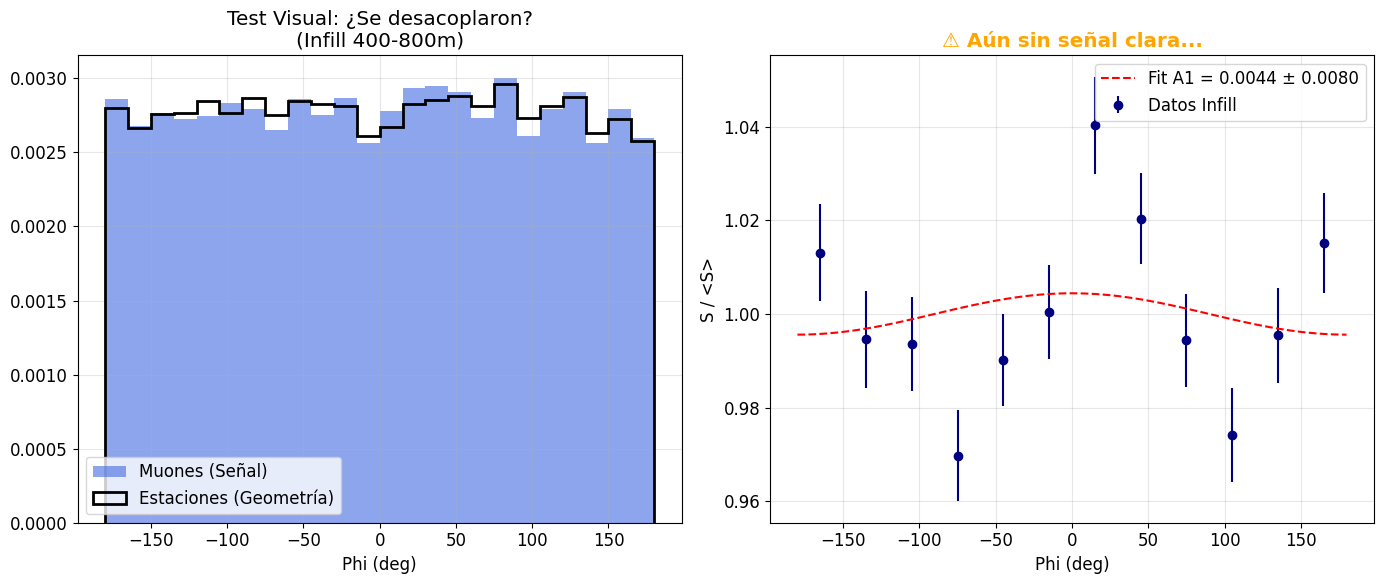

In [50]:
# --- CONFIGURACIÓN ---
FOLDER = "/home/lsilva/Github/ADST_Alexey_module_v6/parquet_sib_helio_17/"

def validar_infill(folder_path):
    print(f"🚀 INICIANDO VALIDACIÓN DEL FIX EN: {folder_path}")
    
    files = glob.glob(os.path.join(folder_path, "*.parquet"))
    if not files: 
        print("❌ No hay archivos.")
        return

    # 1. Cargar datos (Solo lo necesario)
    print("... Cargando datos ...")
    df_list = []
    for f in files: # Si son muchos, podes poner files[:5] para probar rápido
        df_list.append(pd.read_parquet(f, columns=['counterId', 'nMuones_REC', 'r_core', 'phi_plane_euler', 'theta_REC']))
    
    df = pd.concat(df_list, ignore_index=True)
    
    # 2. FILTRO DURO: Solo Infill (Excluir 90k)
    df = df[~((df['counterId'] >= 90000) & (df['counterId'] < 100000))].copy()
    
    # 3. FILTRO RADIAL: Buscamos donde la física ayuda (lejos del core)
    r_min, r_max = 400, 800
    df = df[(df['r_core'] >= r_min) & (df['r_core'] < r_max)].copy()
    
    # 4. FILTRO ANGULAR: Solo inclinados (donde hay asimetría)
    df = df[df['theta_REC'] > 35].copy()
    df = df[df['theta_REC'] < 50].copy()
    
    if df.empty:
        print("⚠️ No hay datos suficientes tras los filtros.")
        return
        
    print(f"✅ Datos filtrados: {len(df)} módulos Infill (r={r_min}-{r_max}m, theta>35°).")

    # --- PREPARAR VARIABLES ---
    # Phi en grados, centrado
    phi_deg = np.rad2deg(df['phi_plane_euler'])
    df['phi_deg'] = (phi_deg + 180) % 360 - 180
    
    # --- PLOT 1: GEOMETRÍA (El Test de la Pistola Humeante) ---
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    # Histograma comparativo
    counts, bins, _ = ax[0].hist(df['phi_deg'], bins=24, weights=df['nMuones_REC'], 
                                 alpha=0.6, label='Muones (Señal)', density=True, color='royalblue')
    
    ax[0].hist(df['phi_deg'], bins=24, histtype='step', linewidth=2, color='k', 
               label='Estaciones (Geometría)', density=True)
    
    ax[0].set_title(f"Test Visual: ¿Se desacoplaron?\n(Infill {r_min}-{r_max}m)")
    ax[0].set_xlabel("Phi (deg)")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    # --- PLOT 2: FIT DE ASIMETRÍA ---
    # Binning para el fit
    n_bins = 12
    phi_bins = np.linspace(-180, 180, n_bins + 1)
    phi_centers = (phi_bins[:-1] + phi_bins[1:]) / 2
    
    df['bin_phi'] = pd.cut(df['phi_deg'], bins=phi_bins)
    
    # Normalización simple por el promedio global del corte (para ver la forma)
    global_mean = df['nMuones_REC'].mean()
    df['norm'] = df['nMuones_REC'] / global_mean
    
    stats = df.groupby('bin_phi', observed=False)['norm'].agg(['mean', 'std', 'count'])
    stats['sem'] = stats['std'] / np.sqrt(stats['count'])
    
    # Datos
    y = stats['mean']
    y_err = stats['sem']
    
    ax[1].errorbar(phi_centers, y, yerr=y_err, fmt='o', color='navy', label='Datos Infill')
    
    # Fit Cosine
    def fit_func(x, A1): return 1 + A1 * np.cos(np.deg2rad(x))
    
    try:
        popt, pcov = curve_fit(fit_func, phi_centers, y, p0=[0.05], sigma=y_err)
        A1 = popt[0]
        err = np.sqrt(pcov[0,0])
        
        x_fit = np.linspace(-180, 180, 100)
        ax[1].plot(x_fit, fit_func(x_fit, *popt), 'r--', label=f'Fit A1 = {A1:.4f} ± {err:.4f}')
        
        # Semáforo de éxito
        if abs(A1) > 3*err and abs(A1) > 0.01:
            ax[1].set_title("✅ ¡SEÑAL DETECTADA!", color='green', fontweight='bold')
        else:
            ax[1].set_title("⚠️ Aún sin señal clara...", color='orange', fontweight='bold')
            
    except:
        ax[1].text(0, 1, "Fit Falló")
        
    ax[1].set_xlabel("Phi (deg)")
    ax[1].set_ylabel("S / <S>")
    ax[1].legend()
    ax[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- EJECUTAR ---
validar_infill(FOLDER)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import glob
import os

FOLDER = "/home/lsilva/Github/ADST_Alexey_module_v5/parquet_sib_helio_17/"

def ajuste_fino_infill(folder_path, r_min=400, r_max=600):
    print(f"🔧 AJUSTE FINO INFILL: {r_min}-{r_max}m")
    
    files = glob.glob(os.path.join(folder_path, "*.parquet"))
    if not files: return

    df_list = []
    # Cargamos theta para filtrar por inclinación
    for f in files: 
        df_list.append(pd.read_parquet(f, columns=['counterId', 'nMuones_REC', 'r_core', 'phi_plane', 'theta_REC']))
    df = pd.concat(df_list, ignore_index=True)
    
    # Filtros
    df = df[~((df['counterId'] >= 90000) & (df['counterId'] < 100000))] # Solo Infill
    df = df[(df['r_core'] >= r_min) & (df['r_core'] < r_max)]
    df = df[df['theta_REC'] > 35] # Solo inclinadas donde hay asimetría
    
    # Phi
    phi_deg = np.rad2deg(df['phi_plane'])
    # Asegurar rango -180 a 180
    df['phi_deg'] = (phi_deg + 180) % 360 - 180
    
    # Normalización simple por promedio global (para ver la forma)
    global_mean = df['nMuones_REC'].mean()
    df['norm'] = df['nMuones_REC'] / global_mean
    
    # Binning
    n_bins = 12
    phi_bins = np.linspace(-180, 180, n_bins + 1)
    phi_centers = (phi_bins[:-1] + phi_bins[1:]) / 2
    
    df['bin_phi'] = pd.cut(df['phi_deg'], bins=phi_bins)
    stats = df.groupby('bin_phi', observed=False)['norm'].agg(['mean', 'std', 'count'])
    stats['sem'] = stats['std'] / np.sqrt(stats['count'])
    
    # Datos
    x = phi_centers
    y = stats['mean'].values
    yerr = stats['sem'].values
    
    # Fit con límites para ayudar a la convergencia
    def fit_func(x, A1, phase): 
        return 1.0 * (1 + A1 * np.cos(np.deg2rad(x - phase)))
    
    # Bounds: A1 entre 0 y 0.5, fase entre -45 y 45 (esperamos pico en 0)
    try:
        popt, pcov = curve_fit(fit_func, x, y, p0=[0.02, 0], sigma=yerr, bounds=([0, -90], [0.5, 90]))
        A1 = popt[0]
        phase = popt[1]
        err_A1 = np.sqrt(pcov[0,0])
        
        print(f"\n✅ RESULTADO DEL FIT:")
        print(f"   Amplitud A1 = {A1:.4f} ± {err_A1:.4f}")
        print(f"   Fase        = {phase:.1f} grad")
        
        # Plot
        plt.figure(figsize=(8, 6))
        plt.errorbar(x, y, yerr=yerr, fmt='o', label='Datos Infill')
        x_fit = np.linspace(-180, 180, 100)
        plt.plot(x_fit, fit_func(x_fit, *popt), 'r-', label=f'Fit A1={A1:.3f}')
        plt.title(f"Asimetría Infill ({r_min}-{r_max}m, Theta>35)")
        plt.xlabel("Phi (deg)")
        plt.ylabel("S / <S>")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
        
    except Exception as e:
        print(f"❌ El fit falló: {e}")

ajuste_fino_infill(FOLDER)

🔧 AJUSTE FINO INFILL: 400-600m
❌ El fit falló: Too large work array required -- computation cannot be performed with standard 32-bit LAPACK.


In [16]:
# Configuración visual
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})

class RadialCutAnalyzer:
    def __init__(self, folder_path):
        """
        Herramienta para estudiar asimetría en cortes radiales específicos.
        Excluye automáticamente el Anillo Denso.
        """
        self.folder_path = folder_path
        self.df = pd.DataFrame()
        self.current_cut_data = None
        self.current_results = []
        
        # Definición de Bins de Theta (Estándar tesis)
        self.n_theta_bins = 6
        self.theta_labels = [] # Se llenan al cargar

    def load_data(self):
        """Carga parquets, limpia y calcula variables geométricas."""
        files = glob.glob(os.path.join(self.folder_path, "*.parquet"))
        if not files:
            print("❌ No se encontraron archivos .parquet")
            return

        print(f"📂 Cargando {len(files)} archivos...")
        df_list = [pd.read_parquet(f) for f in files]
        self.df = pd.concat(df_list, ignore_index=True)
        
        # 1. EXCLUIR ANILLO DENSO (90k)
        # Nos quedamos solo con Infill/Standard (IDs != 90xxx)
        self.df = self.df[~((self.df['counterId'] >= 90000) & (self.df['counterId'] < 100000))].copy()
        
        # 2. FILTROS BÁSICOS
        self.df = self.df[
            (self.df['nMuones_REC'].notna()) &
            (self.df['r_core'].notna())
        ].copy()

        # 3. GEOMETRÍA
        # Theta
        self.df['s2_theta'] = np.sin(np.deg2rad(self.df['theta_REC']))**2
        
        # Phi (Centrado en 0)
        phi_deg = np.rad2deg(self.df['phi_plane'])
        self.df['phi_deg'] = (phi_deg + 180) % 360 - 180
        
        # 4. BINNING EN THETA (Fijo para comparar)
        theta_max = min(65, self.df['theta_REC'].max())
        s2_bins = np.linspace(
            np.sin(np.deg2rad(self.df['theta_REC'].min()))**2,
            np.sin(np.deg2rad(theta_max))**2,
            self.n_theta_bins + 1
        )
        self.df['theta_bin'] = pd.cut(self.df['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)
        
        # Guardar etiquetas para plots
        edges = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))
        self.theta_labels = [f"{edges[i]:.1f}-{edges[i+1]:.1f}°" for i in range(len(edges)-1)]
        
        print(f"✅ Datos listos: {len(self.df)} módulos (Sin Anillo Denso).")

    def _fit_func(self, phi, A1):
        # Fase fija en 0, Offset fijo en 1
        return 1.0 * (1 + A1 * np.cos(np.deg2rad(phi)))

    def analizar_corte(self, r_min, r_max):
        """
        Analiza un anillo específico entre r_min y r_max.
        """
        print(f"\n🔍 Analizando Corte Radial: {r_min} m < r < {r_max} m")
        
        # 1. Filtrar por Radio
        self.current_cut_data = self.df[
            (self.df['r_core'] >= r_min) & 
            (self.df['r_core'] < r_max)
        ].copy()
        
        if self.current_cut_data.empty:
            print("⚠️ No hay datos en este rango radial.")
            return

        print(f"   -> Módulos encontrados: {len(self.current_cut_data)}")
        
        # 2. Ajuste por Bin de Theta
        phi_bins = np.linspace(-180, 180, 13)
        phi_centers = (phi_bins[:-1] + phi_bins[1:]) / 2
        
        results = []
        
        # Preparamos plot de validación (6 subplots)
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
        fig.suptitle(f"Ajustes de Modulación Azimutal (Radio {r_min}-{r_max} m)", fontsize=16)
        axes = axes.flatten()

        for i in range(self.n_theta_bins):
            ax = axes[i]
            subset = self.current_cut_data[self.current_cut_data['theta_bin'] == i]
            
            if len(subset) < 50:
                ax.text(0.5, 0.5, "Poca Estadística", ha='center')
                continue
                
            # Perfil
            subset['phi_hist'] = pd.cut(subset['phi_deg'], bins=phi_bins)
            stats = subset.groupby('phi_hist', observed=True)['nMuones_REC'].agg(['mean', 'std', 'count'])
            
            norm = stats['mean'].mean()
            y = stats['mean'] / norm
            yerr = (stats['std'] / np.sqrt(stats['count'])) / norm
            
            # Plot Datos
            ax.errorbar(phi_centers, y, yerr=yerr, fmt='o', color='navy', label='Datos')
            
            # Fit
            try:
                popt, pcov = curve_fit(self._fit_func, phi_centers, y, p0=[0.05], sigma=yerr)
                A1 = popt[0]
                A1_err = np.sqrt(pcov[0,0])
                
                # Plot Fit
                x_fit = np.linspace(-180, 180, 100)
                ax.plot(x_fit, self._fit_func(x_fit, *popt), 'r--', label=f'A1={A1:.3f}')
                
                results.append({'theta_bin': i, 'A1': A1, 'A1_err': A1_err})
            except:
                ax.text(0, 1.05, "Fit Falló")
            
            ax.set_title(self.theta_labels[i])
            ax.grid(True, alpha=0.3)
            if i == 0: ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()
        
        self.current_results = pd.DataFrame(results)
        
        # 3. Plot Resumen A1 vs Theta para este radio
        if not self.current_results.empty:
            self.plot_summary(r_min, r_max)

    def plot_summary(self, r_min, r_max):
        """Muestra A1 vs Theta para el corte actual."""
        fig, ax = plt.subplots(figsize=(8, 5))
        
        res = self.current_results
        ax.errorbar(res['theta_bin'], res['A1'], yerr=res['A1_err'], 
                    fmt='o-', color='darkgreen', capsize=4, label='UMD REC')
        
        ax.set_title(f"Amplitud de Asimetría vs Theta\nCorte Radial: {r_min} - {r_max} m")
        ax.set_xlabel("Bin de Theta")
        ax.set_ylabel(r"$A_1$")
        ax.set_xticks(range(self.n_theta_bins))
        ax.set_xticklabels(self.theta_labels)
        ax.axhline(0, color='gray', linestyle='--')
        ax.grid(True, alpha=0.5)
        
        plt.show()

📂 Cargando 20 archivos...
✅ Datos listos: 748638 módulos (Sin Anillo Denso).

🔍 Analizando Corte Radial: 400 m < r < 600 m
   -> Módulos encontrados: 123300


/tmp/ipykernel_3930141/448254236.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['phi_hist'] = pd.cut(subset['phi_deg'], bins=phi_bins)
/tmp/ipykernel_3930141/448254236.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['phi_hist'] = pd.cut(subset['phi_deg'], bins=phi_bins)
/tmp/ipykernel_3930141/448254236.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

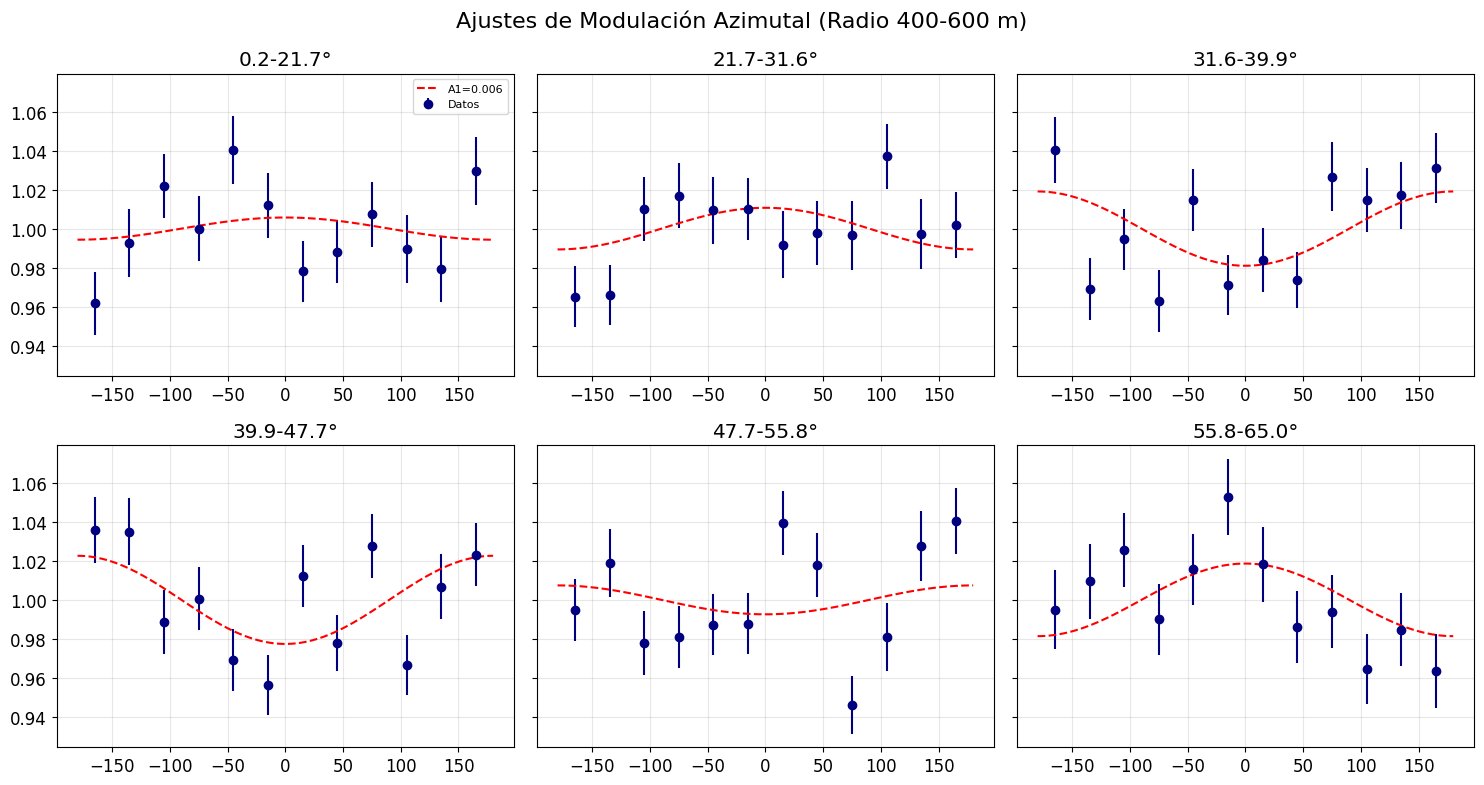

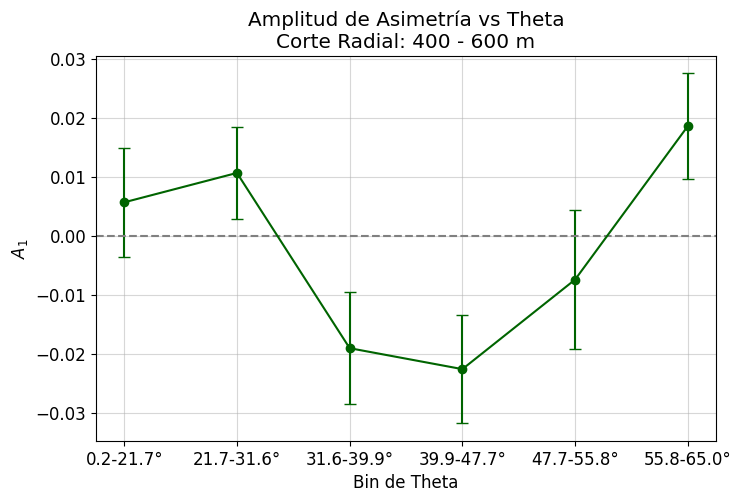

In [18]:
# --- EJEMPLO DE USO ---
# 1. Definí tu carpeta
folder = "/home/lsilva/Github/ADST_Alexey_module_v5/parquet_sib_helio_17/" # Poné la ruta real acá

# 2. Instanciá y cargá
analyzer = RadialCutAnalyzer(folder)
analyzer.load_data()

# 3. ¡Jugá con los cortes! 
analyzer.analizar_corte(r_min=400, r_max=600)   # Cerca
# analyzer.analizar_corte(r_min=600, r_max=1000)  # Medio
# analyzer.analizar_corte(r_min=1000, r_max=2000) # Lejos

In [33]:
def readADST_surface_v10_diagnostic(fname, is_mc_simulation=True):
    """
    Versión DIAGNÓSTICA (v10.2).
    - Fix Core: Usa GetCoreSiteCS() o variantes.
    - Fix Estación: Usa geo.GetStationPosition(sdId) (INFALIBLE).
    """
    
    if not os.path.exists(fname):
        return pd.DataFrame() 

    # --- Inicialización de ROOT ---
    files = ROOT.std.vector('string')()
    files.push_back(fname)

    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    
    file1.ReadDetectorGeometry(geo) # Cargamos la geometría maestra
    file1.SetBuffers(event)

    data = [] 
    event_count = 0

    # --- COMIENZA EL BUCLE DE EVENTOS ---
    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        event_count += 1
        
        # --- Info Global del Evento ---
        event_id_lluvia = event.GetEventId()
        
        # Simulación
        MCShower = event.GetGenShower()
        if not MCShower: continue # Protección si no hay MC
        
        mc_energy = MCShower.GetEnergy()
        logE_MC = np.log10(mc_energy) if mc_energy > 0 else np.nan
        theta_MC = MCShower.GetZenith() * 180.0 / np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0 / np.pi
        
        # Reconstrucción
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        
        if not sShower: continue # Protección
        
        rec_energy = sShower.GetEnergy()
        logE_REC = np.log10(rec_energy) if rec_energy > 0 else np.nan
        theta_REC = sShower.GetZenith() * 180.0 / np.pi
        phi_REC = sShower.GetAzimuth() * 180.0 / np.pi
        
        rec_theta_rad = sShower.GetZenith()
        rec_phi_rad = sShower.GetAzimuth()
        
        # --- 🔧 FIX 1: OBTENCIÓN DEL CORE 🔧 ---
        if hasattr(sShower, "GetCoreSiteCS"):
            pos_core = sShower.GetCoreSiteCS()
        elif hasattr(sShower, "GetCoreSite"):
            pos_core = sShower.GetCoreSite()
        else:
            pos_core = sShower.GetCore()
        # ---------------------------------------

        # --- Bucle sobre los COUNTERS ---
        mEvent = event.GetMDEvent()
        counterIterator = mEvent.CountersBegin()
        countersEnd = mEvent.CountersEnd()
        
        while counterIterator != countersEnd:
            
            counter = counterIterator.__deref__() 
            counterId = counter.GetId()            
            sdId = counter.GetSdPartnerId()    

            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            
            if sdStation is None:
                counterIterator += 1 
                continue 
            
            # --- Info Básica ---
            is_sd_saturated = sdStation.IsLowGainSaturated()
            sdSignal = sdStation.GetTotalSignal()
            
            # --- 🔧 FIX 2: POSICIÓN DESDE GEOMETRÍA MAESTRA 🔧 ---
            # Usamos la función que encontraste en la lista: GetStationPosition()
            # Se la pedimos a 'geo', no a la estación.
            try:
                pos_station = geo.GetStationPosition(sdId)
            except:
                # Si falla, saltamos esta estación
                counterIterator += 1
                continue
            # -----------------------------------------------------

            # ============================================================
            # 🧪 LABORATORIO DE GEOMETRÍA 🧪
            # ============================================================
            
            # A: Offline GetAzimuthSP
            val_sp = sdStation.GetAzimuthSP()
            phi_plane_v8_SP = (val_sp + 2 * np.pi) % (2 * np.pi)

            # B: Resta simple en el suelo (2D)
            dx_ground = pos_station.X() - pos_core.X()
            dy_ground = pos_station.Y() - pos_core.Y()
            phi_ground_abs = np.arctan2(dy_ground, dx_ground)
            phi_plane_ground = (phi_ground_abs - rec_phi_rad + 2 * np.pi) % (2 * np.pi)

            # C: Rotación de Euler (3D Correcta)
            v_rel = ROOT.TVector3(dx_ground, dy_ground, pos_station.Z() - pos_core.Z())
            v_rel.RotateZ(-rec_phi_rad)
            v_rel.RotateY(-rec_theta_rad)
            
            x_plane = v_rel.X()
            y_plane = v_rel.Y()
            r_plane_euler = np.sqrt(x_plane**2 + y_plane**2)
            
            phi_raw_euler = np.arctan2(y_plane, x_plane)
            phi_plane_euler = (phi_raw_euler + 2 * np.pi) % (2 * np.pi)
            
            # ============================================================

            simCounter = mEvent.GetSimCounter(counterId)
            if simCounter is None:
                counterIterator += 1
                continue
            
            modules = getModuleList(counter, sim=is_mc_simulation)
            for module in modules:
                nMuones_REC = module.GetNumberOfEstimatedMuons()
                moduleId = module.GetId()
                
                if module.IsCandidate(): status = "candidate"
                elif module.IsSaturated(): status = "saturated"
                elif module.IsRejected(): status = "rejected"
                elif module.IsSilent(): status = "silent"
                else: status = "undefined"

                nMuones_MC_module = 0.0
                channelIterator = module.ChannelsBegin()
                channelsEnd = module.ChannelsEnd()
                while channelIterator != channelsEnd:
                    channel = channelIterator.__deref__()
                    channelId = channel.GetId()
                    if simCounter.HasSimScintillatorByChannel(moduleId, channelId):
                        mdSimScintillator = simCounter.GetSimScintillatorByChannelId(moduleId, channelId)
                        nMuones_MC_module += mdSimScintillator.GetNumberOfInjectedMuons()
                    channelIterator += 1

                data.append({
                    "event_id": event_id_lluvia,
                    "sdId": sdId,
                    "counterId": counterId,
                    "moduleId": moduleId,
                    "logE_REC": logE_REC, 
                    "theta_REC": theta_REC, 
                    "phi_REC": phi_REC,
                    "theta_MC": theta_MC,
                    
                    "phi_plane_v8_SP": phi_plane_v8_SP,
                    "phi_plane_ground": phi_plane_ground,
                    "phi_plane_euler": phi_plane_euler,
                    
                    "r_core": r_plane_euler,
                    "nMuones_REC": nMuones_REC,   
                    "nMuones_MC": nMuones_MC_module, 
                    "sdSignal": sdSignal,
                    "is_sd_saturated": is_sd_saturated,
                    "module_status": status
                })

            counterIterator += 1 
        
    return pd.DataFrame(data)

In [34]:
# -----------------------------------------------------------------
# FUNCIÓN "TRABAJADORA"
# ❗️ 2. AHORA ACEPTA 'output_dir' COMO ARGUMENTO
# -----------------------------------------------------------------
def process_file_wrapper_v10(root_fpath, output_dir):
    
    # 1. Definir rutas
    filename = os.path.basename(root_fpath)
    output_filename = filename.replace(".root", ".parquet")
    output_path = os.path.join(output_dir, output_filename)
    
    # 2. Evitar reprocesar
    if os.path.exists(output_path):
        return f"INFO: El archivo ya existe, saltando: {output_filename}"

    # 3. Imprimir estado
    print(f"► [Iniciando]: {filename}")
    
    try:
        # ----- INICIO DEL TRABAJO -----
        start_file_time = time.time()
        
        # 1. Leer el .root (¡Llama a la función de la Celda 2.1!)
        # (Asegurate de que tu Celda 2.1 se llame 'readADST_surface' 
        # o cambiá el nombre aquí abajo)
        df = readADST_surface_v10_diagnostic(root_fpath) 
        
        if df.empty:
            return f"INFO: Archivo vacío o sin datos UMD. Saltando: {filename}"

        # 2. Extraer metadatos del nombre de archivo
        try:
            parts = filename.split('_')
            df["model_mc"] = parts[0]
            df["e_min_mc"] = float(parts[1]) / 10.0
            df["e_max_mc"] = float(parts[2]) / 10.0
            df["primary_name_mc"] = parts[3]
            run_part = parts[-1].replace('.root', '')
            df["run_number"] = int(run_part.replace('Run', ''))
        except Exception as e_parse:
            print(f"  Advertencia: No se pudo parsear metadata en {filename}: {e_parse}")

        # 3. Guardar en Parquet
        df.to_parquet(
            output_path,
            compression="snappy",
            index=False
        )
        
        # 4. Liberar memoria
        del df
        
        end_file_time = time.time()
        elapsed = end_file_time - start_file_time
        return f"✔ [Éxito]: {filename} -> {output_filename} ({elapsed:.2f}s)"

        # ----- FIN DEL TRABAJO -----

    except Exception as e:
        # Si algo falla, retornamos el string de error
        return f"❌ [ERROR] en {filename}: {e}\n{traceback.format_exc()}"

In [35]:
# -----------------------------------------------------------------
# SCRIPT PRINCIPAL
# -----------------------------------------------------------------

print("--- INICIANDO PROCESO PARALELO (4 Workers) ---")
start_total_time = time.time()

# --- 1. Configuración de Rutas ---
base_path = "/srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium"
output_dir = "/home/lsilva/Github/ADST_Alexey_module_v6/parquet_sib_helio_17/"

os.makedirs(output_dir, exist_ok=True)
print(f"Buscando archivos en: {base_path}")
print(f"Los archivos .parquet se guardarán en: {output_dir}")

# --- 2. Encontrar todos los archivos ---
all_root_files = glob.glob(os.path.join(base_path, "*.root"))
all_root_files.sort()

if not all_root_files:
    print(f"¡Error! No se encontraron archivos .root en: {base_path}")
else:
    print(f"Encontrados {len(all_root_files)} archivos .root para procesar.")

    # --- 3. Bucle de Procesamiento Paralelo ---
    n_workers = 4  # Ajustar como sea necesario
    print(f"Iniciando Pool con {n_workers} trabajadores...")
    
    # CREAMOS LA FUNCIÓN "PARCIAL" 
    # "Congelamos" el argumento 'output_dir' de nuestra función wrapper
    process_func = partial(process_file_wrapper_v10, output_dir=output_dir)

    with Pool(processes=n_workers) as pool:
        
        # pool.map() distribuye la lista 'all_root_files'
        # entre los 4 trabajadores y aplica la función 'process_file_wrapper'
        # results' será una lista con los strings de "Éxito" o "ERROR"
        results = pool.map(process_func, all_root_files)
        
    print("\n\n--- Proceso Paralelo Completado ---")

    # --- 4. Resumen Final ---
    exitos = 0
    errores = 0
    
    # Imprimimos todos los mensajes de resultado
    for res in results:
        print(res)
        if "✔ [Éxito]" in res:
            exitos += 1
        elif "❌ [ERROR]" in res:
            errores += 1

    end_total_time = time.time()
    print("\n--- Resumen de la Tanda ---")
    print(f"Tiempo total: {(end_total_time - start_total_time) / 60:.2f} minutos")
    print(f"Total de archivos: {len(all_root_files)}")
    print(f"Éxitos: {exitos}")
    print(f"Errores: {errores}")
    print(f"¡Listo! Tus archivos .parquet están en: {output_dir}")

--- INICIANDO PROCESO PARALELO (4 Workers) ---
Buscando archivos en: /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium
Los archivos .parquet se guardarán en: /home/lsilva/Github/ADST_Alexey_module_v6/parquet_sib_helio_17/
Encontrados 20 archivos .root para procesar.
Iniciando Pool con 4 trabajadores...
► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run014.root► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run012.root► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run031.root



► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run032.root
► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run011.root
► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run030.root
► [Iniciando]: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run013.root
► [Inician

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [36]:
# ==========================================
# PARTE 1: CARGA Y LIMPIEZA (Tu código)
# ==========================================

# --- 1. Cargar el "Mega-DataFrame" ---
# Ajustá este path si es necesario
parquet_dir = "/home/lsilva/Github/ADST_Alexey_module_v6/parquet_sib_helio_17/"
all_parquet_files = glob.glob(os.path.join(parquet_dir, "*.parquet"))
all_parquet_files.sort()

print(f"Encontrados {len(all_parquet_files)} archivos .parquet.")

df_list = []
for fpath in all_parquet_files:
    df_list.append(pd.read_parquet(fpath))

# Concatenamos todo
df_new = pd.concat(df_list, ignore_index=True)

# --- 2. Limpieza y Reporte ---
   
# 1. Guardamos la cantidad inicial
n_rows_inicial = len(df_new)
   
# 2. Reemplazar infinitos por NaN
df_new.replace([np.inf, -np.inf], np.nan, inplace=True)
   
# 3. Ver dónde están los problemas antes de borrar
nans_count = df_new[['logE_REC', 'theta_REC', 'phi_REC']].isna().sum()
   
# 4. Ejecutar el drop
df_new.dropna(subset=['logE_REC', 'theta_REC', 'phi_REC'], inplace=True)
   
# 5. Calcular la diferencia
n_rows_final = len(df_new)
n_dropped = n_rows_inicial - n_rows_final
percent_dropped = (n_dropped / n_rows_inicial) * 100 if n_rows_inicial > 0 else 0

# --- IMPRIMIR REPORTE ---
print("\n" + "="*40)
print("REPORTE DE LIMPIEZA DE DATOS")
print("="*40)
print(f"Filas Iniciales:     {n_rows_inicial:10d}")
print(f"Filas Eliminadas:    {n_dropped:10d} ({percent_dropped:.2f}%)")
print(f"Filas Finales:       {n_rows_final:10d}")
print("-" * 40)
if n_dropped > 0:
    print("Causas (NaNs por columna):")
    print(nans_count[nans_count > 0].to_string())
print("="*40 + "\n")

print(f"DataFrame 'df_new' (módulos) cargado y limpio.")
print(f"Primeras filas:\n{df_new.head()}")
print(df_new.columns)



Encontrados 20 archivos .parquet.

REPORTE DE LIMPIEZA DE DATOS
Filas Iniciales:         758097
Filas Eliminadas:         27246 (3.59%)
Filas Finales:           730851
----------------------------------------
Causas (NaNs por columna):
logE_REC    27246

DataFrame 'df_new' (módulos) cargado y limpio.
Primeras filas:
                                            event_id  sdId  counterId  \
0  Library_Prague_Santos_Yushkov:Run_10000:Shower...  4009     104009   
1  Library_Prague_Santos_Yushkov:Run_10000:Shower...  4009     104009   
2  Library_Prague_Santos_Yushkov:Run_10000:Shower...  4009     104009   
3  Library_Prague_Santos_Yushkov:Run_10000:Shower...  4010     104010   
4  Library_Prague_Santos_Yushkov:Run_10000:Shower...  4010     104010   

   moduleId   logE_REC  theta_REC     phi_REC   theta_MC  phi_plane_v8_SP  \
0         1  17.424415   9.516247  269.459517  10.497525         4.663521   
1         2  17.424415   9.516247  269.459517  10.497525         4.663521   
2         3 

Analizando 730851 registros del Infill/Standard...


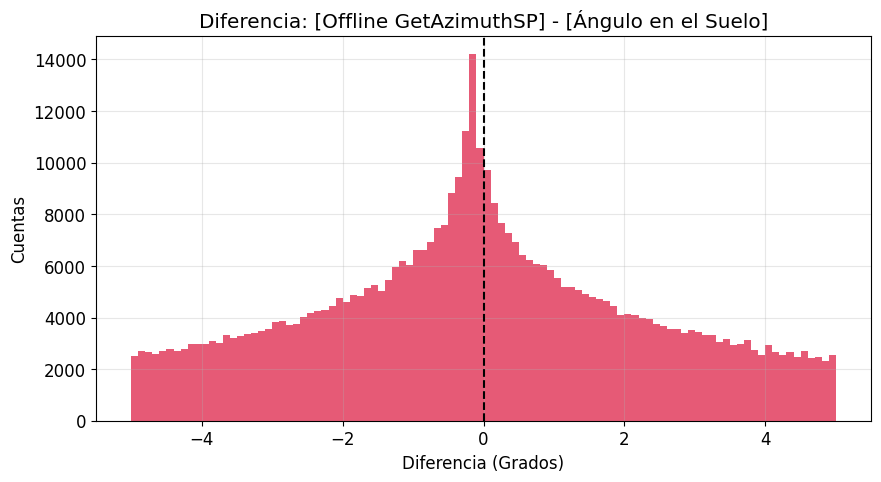

INTERPRETACIÓN 1:
Si ves un PICO GIGANTE en 0, significa que el Offline NO corrige la proyección.
Estaba usando el ángulo del suelo, lo cual 'lava' la asimetría A1.


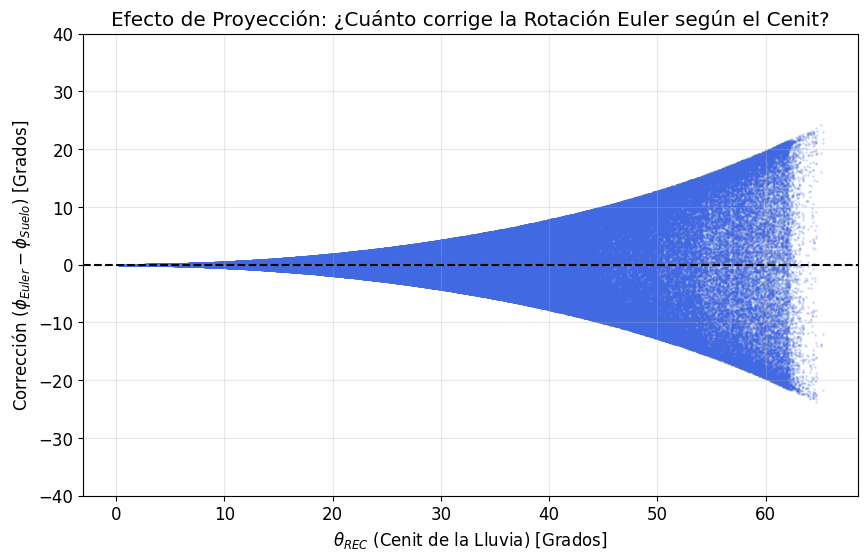

INTERPRETACIÓN 2:
Deberías ver una forma de 'trompeta' o 'mariposa'.
- A Theta=0 (vertical), la corrección es 0.
- A Theta=60, la corrección llega a ser de +/- 20 grados.
Esa corrección de 20 grados es lo que te faltaba para ver la señal A1.


In [37]:
# 1. Filtramos solo INFILL / STANDARD (Sacamos el Anillo Denso 90k que sabemos que anda bien)
#    Las estaciones estándar suelen tener IDs bajos (< 90000)
df_infill = df_new[(df_new['sdId'] < 90000) & (df_new['sdId'] > 0)].copy()

print(f"Analizando {len(df_infill)} registros del Infill/Standard...")

# --- Función auxiliar para diferencia angular segura ---
def ang_diff(a, b):
    # Calcula la diferencia en grados manejando el salto 0-360
    d = np.degrees(a - b)
    return (d + 180) % 360 - 180

# =================================================================
# PRUEBA 1: ¿El Offline nos estaba dando el ángulo del suelo?
# Hipótesis: GetAzimuthSP en Infill == Ángulo Geométrico (MALO)
# =================================================================
diff_offline_ground = ang_diff(df_infill['phi_plane_v8_SP'], df_infill['phi_plane_ground'])

plt.figure(figsize=(10, 5))
plt.hist(diff_offline_ground, bins=100, range=(-5, 5), color='crimson', alpha=0.7)
plt.title("Diferencia: [Offline GetAzimuthSP] - [Ángulo en el Suelo]")
plt.xlabel("Diferencia (Grados)")
plt.ylabel("Cuentas")
plt.axvline(0, color='black', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

print("INTERPRETACIÓN 1:")
print("Si ves un PICO GIGANTE en 0, significa que el Offline NO corrige la proyección.")
print("Estaba usando el ángulo del suelo, lo cual 'lava' la asimetría A1.")

# =================================================================
# PRUEBA 2: La "Trompeta" de Euler (La Corrección Física)
# Hipótesis: La diferencia entre Euler (bien) y Suelo (mal) crece con Theta.
# =================================================================
diff_euler_ground = ang_diff(df_infill['phi_plane_euler'], df_infill['phi_plane_ground'])

plt.figure(figsize=(10, 6))
# Usamos un scatter con puntos muy chicos y transparencia para ver la densidad
plt.scatter(df_infill['theta_REC'], diff_euler_ground, s=1, alpha=0.05, color='royalblue')

plt.title("Efecto de Proyección: ¿Cuánto corrige la Rotación Euler según el Cenit?")
plt.xlabel(r"$\theta_{REC}$ (Cenit de la Lluvia) [Grados]")
plt.ylabel(r"Corrección ($\phi_{Euler} - \phi_{Suelo}$) [Grados]")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='k', linestyle='--')
plt.ylim(-40, 40) # Limitamos para ver bien el centro
plt.show()

print("INTERPRETACIÓN 2:")
print("Deberías ver una forma de 'trompeta' o 'mariposa'.")
print("- A Theta=0 (vertical), la corrección es 0.")
print("- A Theta=60, la corrección llega a ser de +/- 20 grados.")
print("Esa corrección de 20 grados es lo que te faltaba para ver la señal A1.")

🔍 Iniciando Diagnóstico en: /home/lsilva/Github/ADST_Alexey_module_v6/parquet_sib_helio_17/

Filtro Aplicado:
 -> Radio: 400 - 800 m
 -> Theta: 40.0° - 60.0°
Datos después del corte: 125541 filas.


/home/lsilva/Github/Tesis-de-Licenciatura---ITeDA/venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/home/lsilva/Github/Tesis-de-Licenciatura---ITeDA/venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/tmp/ipykernel_3930141/547264211.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(pd.cut(data['phi_deg'], bins))


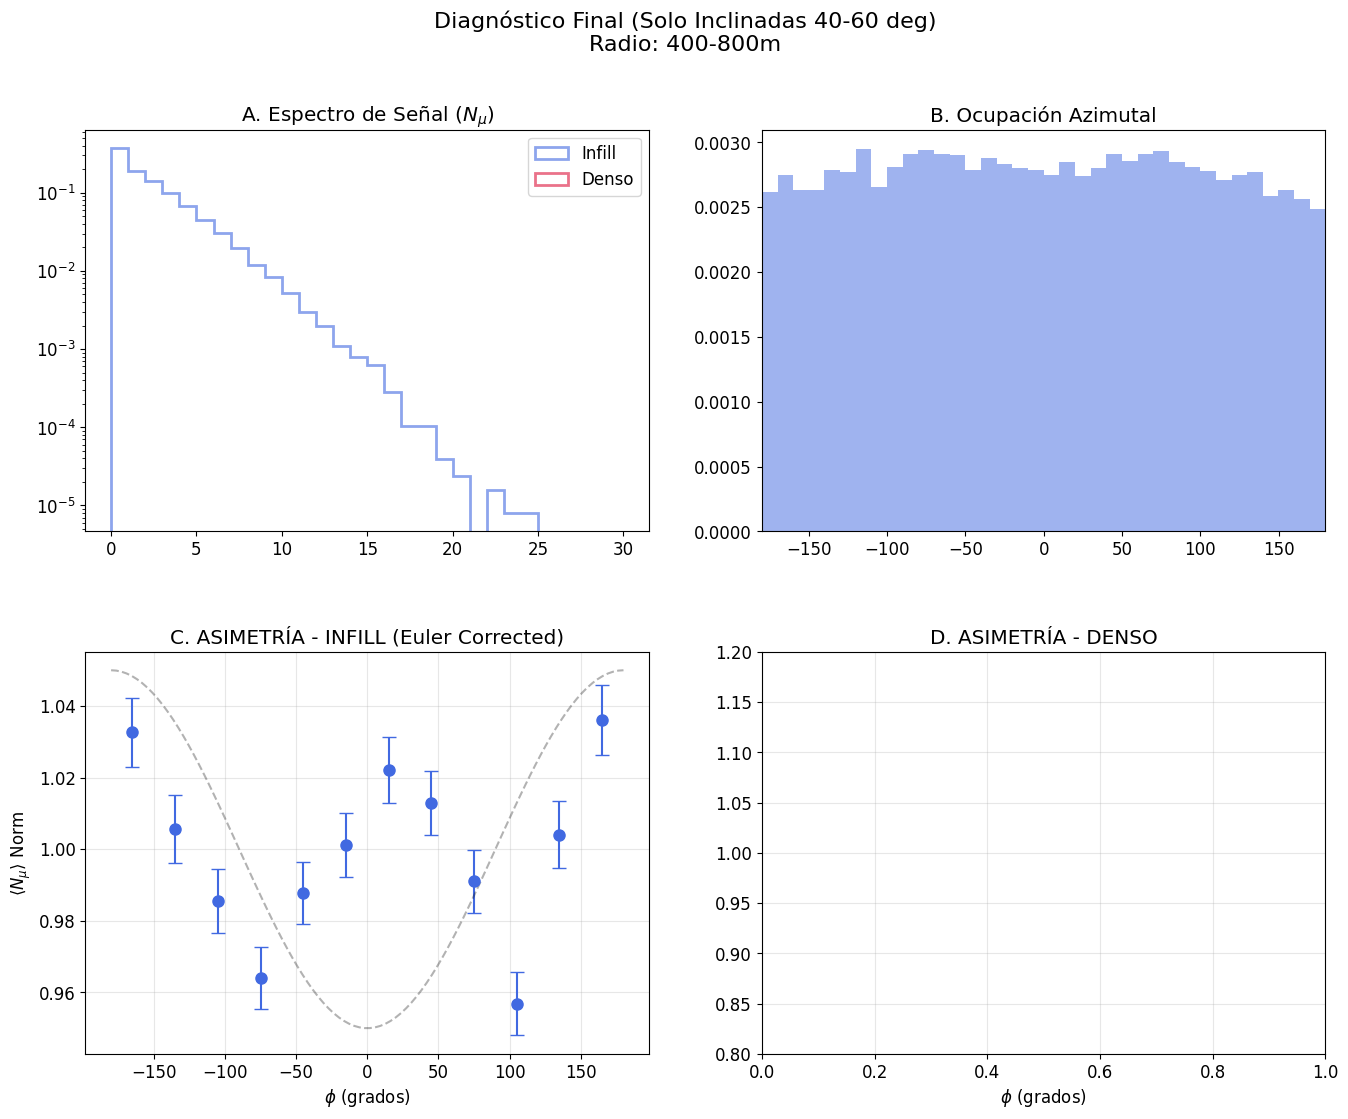

In [61]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
FOLDER_PATH = "/home/lsilva/Github/ADST_Alexey_module_v6/parquet_sib_helio_17/"

def diagnostico_infill_vs_denso_final(folder):
    print(f"🔍 Iniciando Diagnóstico en: {folder}")
    
    # 1. CARGA DE DATOS
    files = glob.glob(os.path.join(folder, "*.parquet"))
    if not files:
        print("❌ No se encontraron archivos.")
        return
    
    cols = [
        'event_id', 'counterId', 'nMuones_REC', 
        'r_core', 'phi_plane_euler', 'module_status', 
        'theta_REC' 
    ]
    
    df_list = []
    # print(f"Leyendo {len(files)} archivos...")
    for f in files:
        try:
            df_list.append(pd.read_parquet(f, columns=cols))
        except Exception as e:
            continue
    
    if not df_list:
        print("❌ No se pudo cargar dataframes.")
        return

    df = pd.concat(df_list, ignore_index=True)
    df.rename(columns={'phi_plane_euler': 'phi_plane'}, inplace=True)
    
    # Filtro calidad
    df = df[df['module_status'].isin(['candidate', 'rejected', 'saturated'])].copy()
    
    # Tipos
    mask_dense = (df['counterId'] >= 90000) & (df['counterId'] < 100000)
    df['type'] = np.where(mask_dense, 'Denso (90k)', 'Infill (Std)')
    
    # --- FILTROS DE FÍSICA ---
    # Volvemos al radio original que sabíamos que tenía datos
    r_min, r_max = 400, 800  
    theta_min, theta_max = 40.0, 60.0 
    
    print(f"\nFiltro Aplicado:")
    print(f" -> Radio: {r_min} - {r_max} m")
    print(f" -> Theta: {theta_min}° - {theta_max}°")

    # Filtro Radial
    mask_r = (df['r_core'] >= r_min) & (df['r_core'] < r_max)
    
    # --- CORRECCIÓN ACÁ ---
    # Como theta_REC ya está en grados en el parquet, lo usamos directo.
    mask_theta = (df['theta_REC'] >= theta_min) & (df['theta_REC'] < theta_max)
    
    cut = df[mask_r & mask_theta].copy()
    print(f"Datos después del corte: {len(cut)} filas.")

    if cut.empty:
        print("⚠️ No hay datos.")
        return

    # --- PLOTS ---
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    
    c_infill = 'royalblue'
    c_dense = 'crimson'

    # A. FLUCTUACIONES
    bins_mu = np.linspace(0, 30, 31)
    axs[0,0].hist(cut[cut['type']=='Infill (Std)']['nMuones_REC'], bins=bins_mu, 
                  alpha=0.6, color=c_infill, label='Infill', density=True, histtype='step', linewidth=2)
    axs[0,0].hist(cut[cut['type']=='Denso (90k)']['nMuones_REC'], bins=bins_mu, 
                  alpha=0.6, color=c_dense, label='Denso', density=True, histtype='step', linewidth=2)
    axs[0,0].set_title(rf"A. Espectro de Señal ($N_\mu$)")
    axs[0,0].set_yscale('log')
    axs[0,0].legend()

    # B. OCUPACIÓN
    phi_deg = np.degrees(cut['phi_plane'])
    phi_deg = (phi_deg + 180) % 360 - 180 
    cut['phi_deg'] = phi_deg

    axs[0,1].hist(cut[cut['type']=='Infill (Std)']['phi_deg'], bins=36, 
                  alpha=0.5, color=c_infill, label='Infill', density=True)
    axs[0,1].hist(cut[cut['type']=='Denso (90k)']['phi_deg'], bins=36, 
                  alpha=0.5, color=c_dense, label='Denso', density=True, histtype='step')
    axs[0,1].set_title("B. Ocupación Azimutal")
    axs[0,1].set_xlim(-180, 180)

    # C y D. PERFIL DE ASIMETRÍA
    def plot_profile(ax, data, label, color):
        bins = np.linspace(-180, 180, 13) 
        groups = data.groupby(pd.cut(data['phi_deg'], bins))
        bin_means = groups['nMuones_REC'].mean()
        bin_sem = groups['nMuones_REC'].sem()
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        mean_global = bin_means.mean()
        if pd.isna(mean_global) or mean_global == 0: return

        y_vals = bin_means / mean_global
        y_err = bin_sem / mean_global
        
        ax.errorbar(bin_centers, y_vals, yerr=y_err, fmt='o', capsize=5, 
                    color=color, label=f'{label} Data', markersize=8)
        
        x_fit = np.linspace(-180, 180, 100)
        y_fit = 1 + 0.05 * np.cos(np.radians(x_fit)+np.pi) 
        ax.plot(x_fit, y_fit, 'k--', alpha=0.3, label='Ref Cosine')

    # Plot C: INFILL
    plot_profile(axs[1,0], cut[cut['type']=='Infill (Std)'], "Infill", c_infill)
    axs[1,0].set_title(r"C. ASIMETRÍA - INFILL (Euler Corrected)")
    axs[1,0].set_xlabel(r"$\phi$ (grados)")
    axs[1,0].set_ylabel(r"$\langle N_\mu \rangle$ Norm")
    axs[1,0].grid(True, alpha=0.3)

    # Plot D: DENSO
    plot_profile(axs[1,1], cut[cut['type']=='Denso (90k)'], "Denso", c_dense)
    axs[1,1].set_title(r"D. ASIMETRÍA - DENSO")
    axs[1,1].set_xlabel(r"$\phi$ (grados)")
    axs[1,1].set_ylim(0.8, 1.2)
    axs[1,1].grid(True, alpha=0.3)

    plt.suptitle(f"Diagnóstico Final (Solo Inclinadas 40-60 deg)\nRadio: {r_min}-{r_max}m", fontsize=16)
    plt.show()

diagnostico_infill_vs_denso_final(FOLDER_PATH)

🔍 Generando Mapa Comparativo: DENSO vs INFILL en /home/lsilva/Github/ADST_Alexey_module_v7/parquet_sib_helio_17/
Filtrando Theta: 40.0° - 60.0° (Zona de Alta Asimetría)
Eventos Denso: 348507 | Eventos Infill: 291570


/tmp/ipykernel_3930141/3513918547.py:85: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(col)


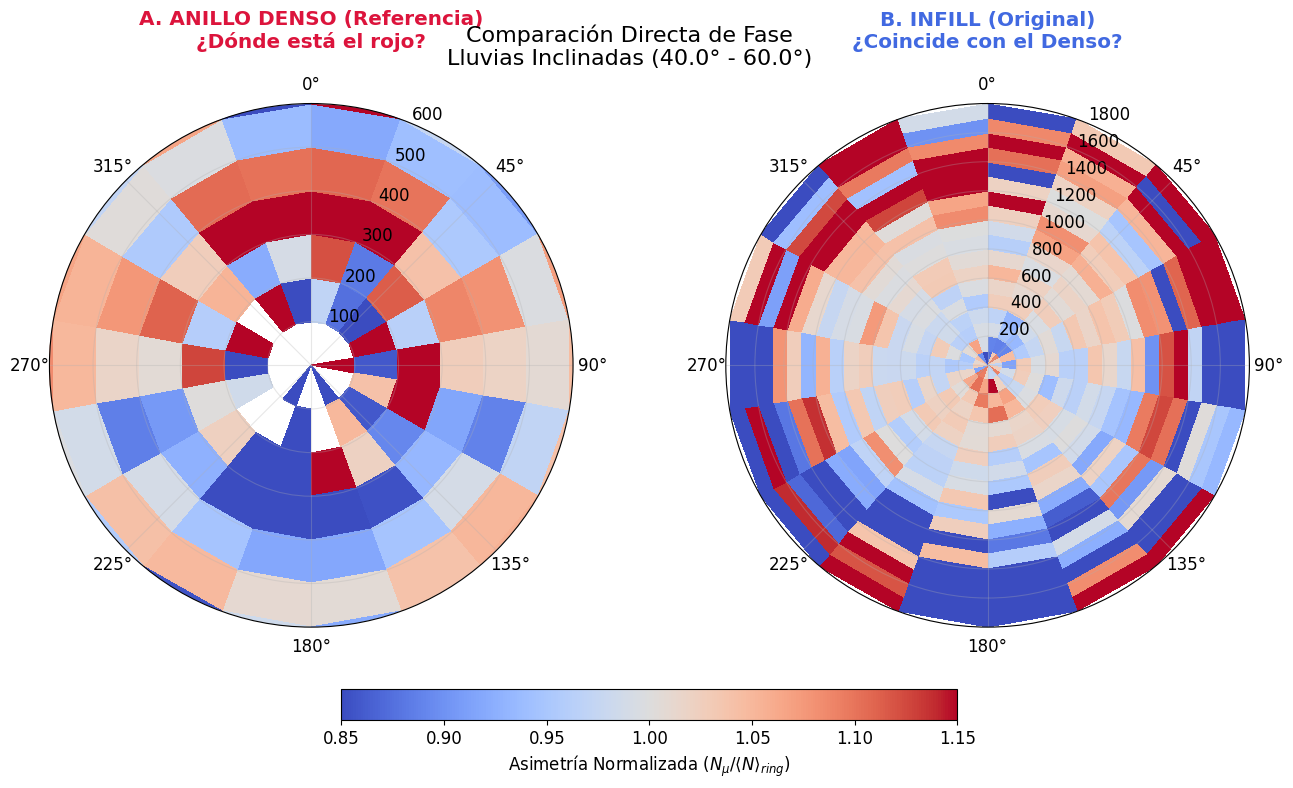

In [71]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
FOLDER_PATH = "/home/lsilva/Github/ADST_Alexey_module_v7/parquet_sib_helio_17/"

def mapa_comparativo_final(folder):
    print(f"🔍 Generando Mapa Comparativo: DENSO vs INFILL en {folder}")
    
    # 1. CARGA
    files = glob.glob(os.path.join(folder, "*.parquet"))
    if not files: return
    
    cols = ['nMuones_REC', 'r_core', 'phi_plane', 'counterId', 'module_status', 'theta_REC']
    df_list = []
    
    for f in files:
        try:
            df_t = pd.read_parquet(f)
            # Normalizar nombre de columna
            if 'phi_plane_euler' in df_t.columns:
                df_t.rename(columns={'phi_plane_euler': 'phi_plane'}, inplace=True)
            # Filtrar columnas si existen
            valid_cols = [c for c in cols if c in df_t.columns]
            df_list.append(df_t[valid_cols])
        except: continue
        
    df = pd.concat(df_list, ignore_index=True)
    
    # 2. FILTROS DE CALIDAD Y FÍSICA
    # Nos quedamos SOLO con lluvias inclinadas donde la asimetría es fuerte
    theta_min, theta_max = 40.0, 60.0
    print(f"Filtrando Theta: {theta_min}° - {theta_max}° (Zona de Alta Asimetría)")
    
    mask_qual = df['module_status'].isin(['candidate', 'rejected', 'saturated'])
    mask_theta = (df['theta_REC'] >= theta_min) & (df['theta_REC'] < theta_max)
    
    df = df[mask_qual & mask_theta].copy()
    
    if df.empty:
        print("❌ No hay datos en el rango angular seleccionado.")
        return

    # 3. SEPARACIÓN DE DATASETS
    # Denso: < 100k (Generalmente radio < 400m, pero usamos todos para ver el mapa)
    df_dense = df[(df['counterId'] >= 90000) & (df['counterId'] < 100000)].copy()
    
    # Infill: >= 100k
    df_infill = df[df['counterId'] >= 100000].copy()
    
    print(f"Eventos Denso: {len(df_dense)} | Eventos Infill: {len(df_infill)}")

    # 4. CONFIGURACIÓN DEL MAPA
    # Usamos bines grandes para suavizar el ruido del Infill
    r_max = 1800
    r_step = 100
    phi_bins = 18 # 20 grados por bin
    
    r_edges = np.arange(0, r_max + r_step, r_step)
    p_edges = np.linspace(0, 2*np.pi, phi_bins + 1)
    R, P = np.meshgrid(r_edges, p_edges)

    # --- FUNCIÓN DE NORMALIZACIÓN RADIAL ---
    def get_norm_grid(dframe):
        if dframe.empty: return np.zeros_like(R)
        
        # Phi en [0, 2pi]
        phi_arr = dframe['phi_plane'] % (2*np.pi)
        
        # Histograma 2D de Muones y de Cuentas
        H_mu, _, _ = np.histogram2d(phi_arr, dframe['r_core'], bins=[p_edges, r_edges], weights=dframe['nMuones_REC'])
        H_n, _, _ = np.histogram2d(phi_arr, dframe['r_core'], bins=[p_edges, r_edges])
        
        # Densidad bruta (Muones por Estación)
        with np.errstate(divide='ignore', invalid='ignore'):
            Z = H_mu / H_n
            
        # Normalización por Anillo (Para eliminar la caída radial)
        Z_norm = np.zeros_like(Z)
        for i in range(Z.shape[1]): # Iterar por anillos (radios)
            col = Z[:, i]
            mean_val = np.nanmean(col)
            if mean_val > 0:
                Z_norm[:, i] = col / mean_val
            else:
                Z_norm[:, i] = np.nan
        return Z_norm

    # 5. GENERAR GRILLAS
    Z_dense = get_norm_grid(df_dense)
    Z_infill = get_norm_grid(df_infill)

    # 6. PLOT COMPARATIVO
    fig, axs = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(polar=True))
    
    # Ajuste de escala de color para resaltar contraste (0.8 a 1.2)
    vmin, vmax = 0.85, 1.15
    cmap = 'coolwarm' # Rojo=Alto, Azul=Bajo
    
    # --- IZQUIERDA: ANILLO DENSO (LA REFERENCIA) ---
    ax = axs[0]
    mesh = ax.pcolormesh(P, R, Z_dense, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    ax.set_theta_zero_location("N") # 0 arriba
    ax.set_theta_direction(-1)      # Horario
    ax.set_rlim(0, 600) # Zoom al centro
    ax.set_title("A. ANILLO DENSO (Referencia)\n¿Dónde está el rojo?", pad=20, fontweight='bold', color='crimson')
    ax.grid(True, alpha=0.3)
    
    # --- DERECHA: INFILL (EL TEST) ---
    ax = axs[1]
    mesh2 = ax.pcolormesh(P, R, Z_infill, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlim(0, r_max)
    ax.set_title("B. INFILL (Original)\n¿Coincide con el Denso?", pad=20, fontweight='bold', color='royalblue')
    ax.grid(True, alpha=0.3)
    
    # Barra de color común
    cbar = fig.colorbar(mesh2, ax=axs.ravel().tolist(), orientation='horizontal', fraction=0.05, pad=0.1)
    cbar.set_label(r"Asimetría Normalizada ($N_\mu / \langle N \rangle_{ring}$)")
    
    plt.suptitle(f"Comparación Directa de Fase\nLluvias Inclinadas ({theta_min}° - {theta_max}°)", fontsize=16)
    plt.show()

mapa_comparativo_final(FOLDER_PATH)

Encontrados 20 archivos.
Datos Infill cargados: 743553 eventos


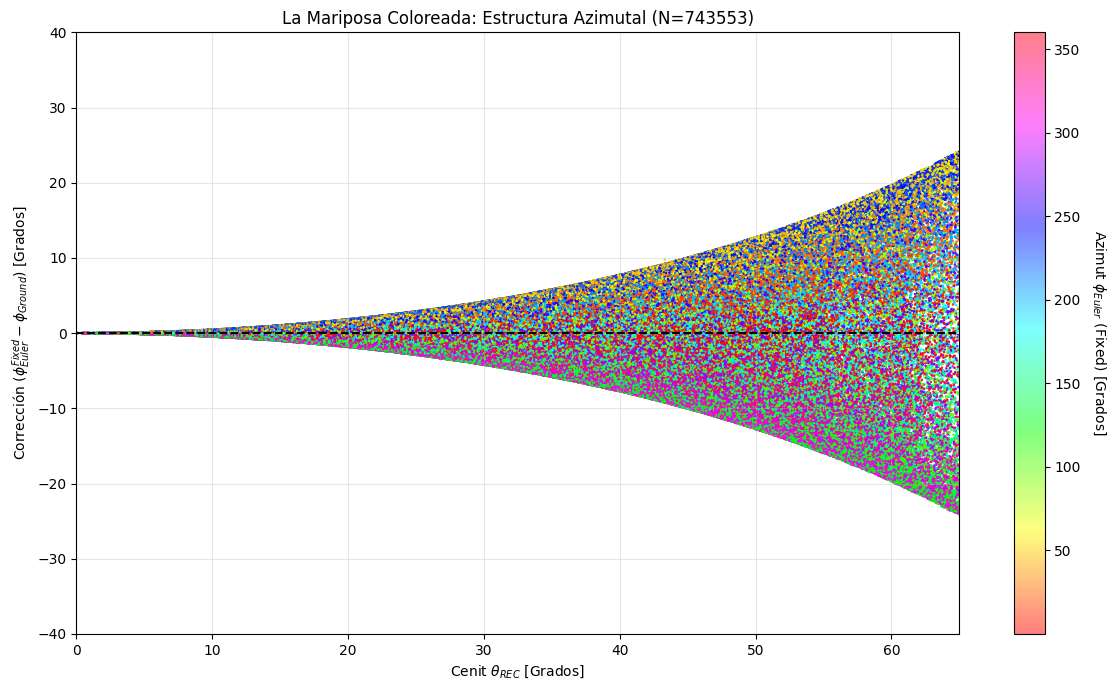

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# --- 1. CONFIGURACIÓN ---
carpeta = "/home/lsilva/Github/ADST_Alexey_module_v8/parquet_qgs_helio_17/" 
files = glob.glob(os.path.join(carpeta, "*.parquet"))

print(f"Encontrados {len(files)} archivos.")

# --- 2. CARGA DE DATOS ---
dfs = []
# Solo cargamos lo necesario para Infill (Euler vs Ground)
cols = ['counterId', 'theta_REC', 'phi_plane_euler', 'phi_plane_ground']

for f in files:
    try:
        df_chunk = pd.read_parquet(f, columns=cols)
        # FILTRO INFILL (Clave del código que me pasaste)
        df_chunk = df_chunk[df_chunk['counterId'] >= 100000]
        if len(df_chunk) > 0:
            dfs.append(df_chunk)
    except Exception as e:
        pass # Ignorar archivos corruptos

if not dfs:
    print("No hay datos de Infill (ID >= 100000).")
    exit()

df = pd.concat(dfs, ignore_index=True)
print(f"Datos Infill cargados: {len(df)} eventos")

# --- 3. LÓGICA DE TU REPORTE ("PARCHES FÍSICOS") ---

def ensure_degrees(series):
    """Detecta si está en radianes y convierte a grados"""
    if series.max() < 7: # Heurística: Si max < 2*pi, es radianes
        return np.degrees(series)
    return series

def ang_diff(a, b):
    """Resta angular cíclica: (a - b) en rango [-180, 180]"""
    diff = a - b
    return (diff + 180) % 360 - 180

# 1. Asegurar Grados
theta = ensure_degrees(df['theta_REC'])
phi_euler = ensure_degrees(df['phi_plane_euler'])
phi_ground = ensure_degrees(df['phi_plane_ground'])

# 2. APLICAR TU PARCHE FÍSICO (Del snippet)
# "vals_euler_fixed = (vals_euler + 180) % 360"
phi_euler_fixed = (phi_euler + 180) % 360

# 3. Calcular Diferencia (Eje Y de la Mariposa)
# "diff_euler_ground = ang_diff(vals_euler_fixed, vals_ground)"
diff_val = ang_diff(phi_euler_fixed, phi_ground)

# --- 4. GRAFICAR ---
plt.figure(figsize=(12, 7))

# Scatter: Theta vs Diferencia, coloreado por el ángulo Euler (Fixed)
sc = plt.scatter(
    theta, 
    diff_val, 
    c=phi_euler_fixed,  # <--- Coloreamos por el ángulo azimutal
    cmap='hsv',         # Mapa cíclico (0=360)
    s=0.5,              # Puntos finos
    alpha=0.5
)

cbar = plt.colorbar(sc)
cbar.set_label(r'Azimut $\phi_{Euler}$ (Fixed) [Grados]', rotation=270, labelpad=20)

plt.axhline(0, color='k', linestyle='--')
plt.xlabel(r'Cenit $\theta_{REC}$ [Grados]')
plt.ylabel(r'Corrección ($\phi_{Euler}^{Fixed} - \phi_{Ground}$) [Grados]')
plt.title(f'La Mariposa Coloreada: Estructura Azimutal (N={len(df)})')

# Límites de tu reporte
plt.xlim(0, 65)
plt.ylim(-40, 40)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Graficando 322845 eventos inclinados...


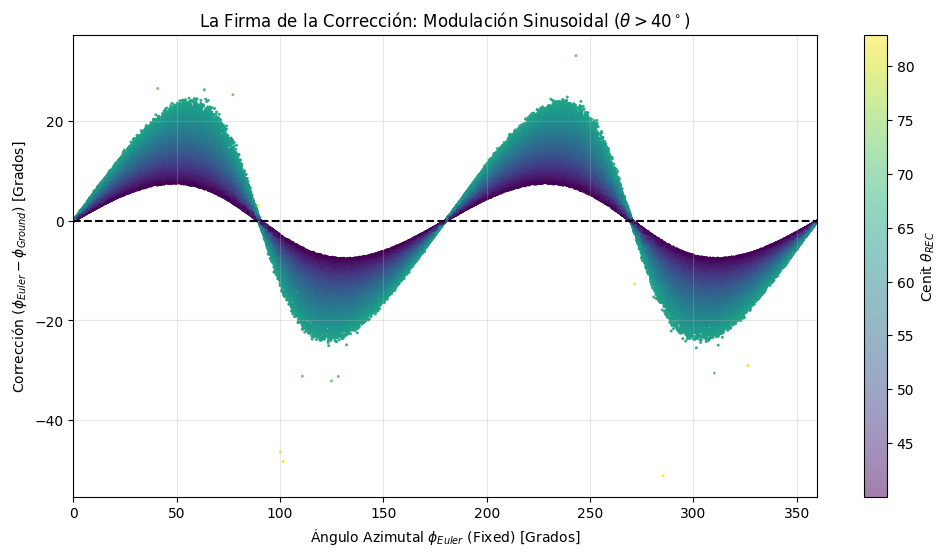

In [13]:
# --- CÓDIGO CORREGIDO ---
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. INTEGRAR LA DIFERENCIA AL DATAFRAME ORIGINAL
# Asumimos que 'diff_val' es la variable que calculaste en el paso anterior (la resta cíclica)
# Si no la tenés en memoria, recalculala rápido aquí:
# diff_val = ang_diff((ensure_degrees(df['phi_plane_euler']) + 180) % 360, ensure_degrees(df['phi_plane_ground']))

df['correction_final'] = diff_val 

# 2. AHORA SÍ, CREAMOS EL SUBSET
# Filtramos solo eventos inclinados para ver bien la onda
subset = df[df['theta_REC'] > 40].copy()

# Aseguramos que phi también esté en grados para el eje X
subset['phi_euler_deg'] = ensure_degrees(subset['phi_plane_euler'])
subset['phi_euler_fixed'] = (subset['phi_euler_deg'] + 180) % 360  # Tu parche de rotación

print(f"Graficando {len(subset)} eventos inclinados...")

plt.figure(figsize=(12, 6))

# 3. GRAFICAMOS USANDO SOLO COLUMNAS DE 'subset'
# Ahora X e Y tienen garantizado el mismo largo
plt.scatter(
    subset['phi_euler_fixed'],   # Eje X: Azimut (del subset)
    subset['correction_final'],  # Eje Y: Diferencia (del subset)
    c=subset['theta_REC'],       # Color: Cenit (del subset)
    cmap='viridis',
    s=1,
    alpha=0.5
)

plt.axhline(0, color='k', linestyle='--')
plt.xlabel(r'Ángulo Azimutal $\phi_{Euler}$ (Fixed) [Grados]')
plt.ylabel(r'Corrección ($\phi_{Euler} - \phi_{Ground}$) [Grados]')
plt.title(r'La Firma de la Corrección: Modulación Sinusoidal ($\theta > 40^\circ$)')
plt.colorbar(label=r'Cenit $\theta_{REC}$')
plt.grid(True, alpha=0.3)
plt.xlim(0, 360)

plt.show()